In [1]:
import numpy as np 
import pandas as pd

In [2]:
df = pd.read_csv('data/IPL_Ball_by_Ball_2008_2022.csv')
df.head()

,ID,innings,overs,ballnumber,batter,bowler,non-striker,extra_type,batsman_run,extras_run,total_run,non_boundary,isWicketDelivery,player_out,kind,fielders_involved,BattingTeam
0,1312200,1,0,1,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals
1,1312200,1,0,2,YBK Jaiswal,Mohammed Shami,JC Buttler,legbyes,0,1,1,0,0,NaN,NaN,NaN,Rajasthan Royals
2,1312200,1,0,3,JC Buttler,Mohammed Shami,YBK Jaiswal,NaN,1,0,1,0,0,NaN,NaN,NaN,Rajasthan Royals
3,1312200,1,0,4,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals
4,1312200,1,0,5,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals


In [3]:
df['player_out'].value_counts()

player_out
RG Sharma                  194
V Kohli                    183
RV Uthappa                 180
S Dhawan                   179
SK Raina                   171
                          ... 
S Lamichhane                 1
P Ray Barman                 1
JPR Scantlebury-Searles      1
ND Doshi                     1
AA Noffke                    1
Name: count, Length: 573, dtype: int64

In [4]:
df.shape

(225954, 17)

In [5]:
df['batter'].value_counts()

batter
V Kohli           5266
S Dhawan          5083
RG Sharma         4632
DA Warner         4313
SK Raina          4177
                  ... 
S Lamichhane         1
JL Denly             1
NJ Rimmington        1
Y Prithvi Raj        1
V Pratap Singh       1
Name: count, Length: 605, dtype: int64

In [6]:
eligible_batsman = df['batter'].value_counts()[df['batter'].value_counts() > 100].index

In [7]:
eligible_batsman

Index(['V Kohli', 'S Dhawan', 'RG Sharma', 'DA Warner', 'SK Raina',
       'RV Uthappa', 'MS Dhoni', 'G Gambhir', 'CH Gayle', 'AB de Villiers',
       ...
       'SE Rutherford', 'RJ Quiney', 'UT Khawaja', 'AB McDonald', 'DJ Harris',
       'SL Malinga', 'B Lee', 'DJM Short', 'RD Chahar', 'DJ Jacobs'],
      dtype='object', name='batter', length=265)

In [8]:
new_df = df[df['batter'].isin(eligible_batsman)]

In [9]:
new_df.shape

(215697, 17)

In [10]:
# average
runs_ser = new_df.groupby('batter').sum()['batsman_run']

In [11]:
runs_ser

batter
A Ashish Reddy      280
A Badoni            161
A Mishra            362
A Symonds           974
AA Jhunjhunwala     217
                   ... 
YBK Jaiswal         547
YK Pathan          3222
YV Takawale         192
Yuvraj Singh       2754
Z Khan              117
Name: batsman_run, Length: 265, dtype: int64

In [12]:
# outs
out_ser = new_df['player_out'].value_counts()

In [13]:
out_ser

player_out
RG Sharma     194
V Kohli       182
RV Uthappa    180
S Dhawan      179
SK Raina      171
             ... 
SA Abbott       1
PV Tambe        1
LJ Wright       1
MS Gony         1
D Salunkhe      1
Name: count, Length: 311, dtype: int64

In [14]:
out_ser = out_ser[out_ser.index.isin(eligible_batsman)]

In [15]:
out_ser

player_out
RG Sharma          194
V Kohli            182
RV Uthappa         180
S Dhawan           179
SK Raina           171
                  ... 
B Sai Sudharsan      4
NK Patel             4
DJ Harris            4
AC Voges             4
MN van Wyk           3
Name: count, Length: 265, dtype: int64

In [16]:
avg_df = (runs_ser/out_ser).reset_index().rename(columns={'index':'batsman',0:'average'})

In [17]:
avg_df

,batsman,average
0,A Ashish Reddy,18.666667
1,A Badoni,20.125000
2,A Mishra,12.066667
3,A Symonds,36.074074
4,AA Jhunjhunwala,16.692308
...,...,...
260,YBK Jaiswal,23.782609
261,YK Pathan,29.559633
262,YV Takawale,24.000000
263,Yuvraj Singh,25.036364


In [18]:
balls_ser = new_df['batter'].value_counts()

In [19]:
balls_ser

batter
V Kohli      5266
S Dhawan     5083
RG Sharma    4632
DA Warner    4313
SK Raina     4177
             ... 
DJ Harris     103
RD Chahar     102
B Lee         102
DJM Short     102
DJ Jacobs     101
Name: count, Length: 265, dtype: int64

In [20]:
sr_df = ((runs_ser/balls_ser)*100).reset_index().rename(columns={'batter':'batsman',0:'strike_rate'})

In [21]:
sr_df

,batsman,strike_rate
0,A Ashish Reddy,142.857143
1,A Badoni,115.827338
2,A Mishra,88.292683
3,A Symonds,124.711908
4,AA Jhunjhunwala,99.541284
...,...,...
260,YBK Jaiswal,133.414634
261,YK Pathan,138.046272
262,YV Takawale,104.918033
263,Yuvraj Singh,124.784776


In [22]:
final_df = avg_df.merge(sr_df, on='batsman')

In [23]:
final_df

,batsman,average,strike_rate
0,A Ashish Reddy,18.666667,142.857143
1,A Badoni,20.125000,115.827338
2,A Mishra,12.066667,88.292683
3,A Symonds,36.074074,124.711908
4,AA Jhunjhunwala,16.692308,99.541284
...,...,...,...
260,YBK Jaiswal,23.782609,133.414634
261,YK Pathan,29.559633,138.046272
262,YV Takawale,24.000000,104.918033
263,Yuvraj Singh,25.036364,124.784776


In [24]:
X = final_df.iloc[:,1:].values

In [25]:
X

array([[ 18.66666667, 142.85714286],
       [ 20.125     , 115.82733813],
       [ 12.06666667,  88.29268293],
       [ 36.07407407, 124.71190781],
       [ 16.69230769,  99.5412844 ],
       [ 17.9       , 111.875     ],
       [ 24.6       , 119.41747573],
       [ 39.85384615, 148.58044164],
       [ 27.22368421, 133.05466238],
       [ 45.25      , 126.57342657],
       [ 24.66666667, 124.3697479 ],
       [ 23.35483871, 120.86811352],
       [ 29.98529412, 168.23432343],
       [ 24.9047619 , 123.3490566 ],
       [ 40.53846154, 131.75      ],
       [ 19.0952381 , 109.26430518],
       [ 17.68421053, 114.28571429],
       [ 30.86363636, 117.57575758],
       [ 14.125     , 118.94736842],
       [ 19.23728814, 123.50380849],
       [ 21.55555556, 112.79069767],
       [ 28.89655172, 124.14814815],
       [ 13.41176471, 139.02439024],
       [ 23.82142857, 130.52837573],
       [ 14.33333333, 104.03225806],
       [ 20.42105263, 124.75884244],
       [ 18.66666667, 109.375     ],
 

C:\Users\rudra\AppData\Local\Temp\ipykernel_7340\3473494768.py:3: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[:, 0], X[:, 1], s=50, cmap='viridis')


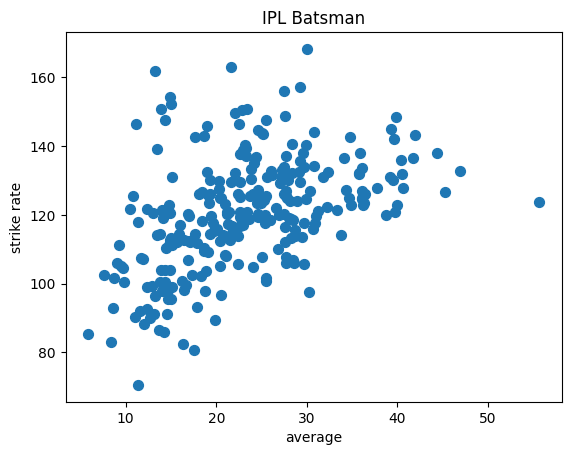

In [26]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1], s=50, cmap='viridis')
plt.title("IPL Batsman")
plt.xlabel("average")
plt.ylabel("strike rate")
plt.show()


In [27]:
from sklearn.cluster import KMeans

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_init = 10, n_clusters = i)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

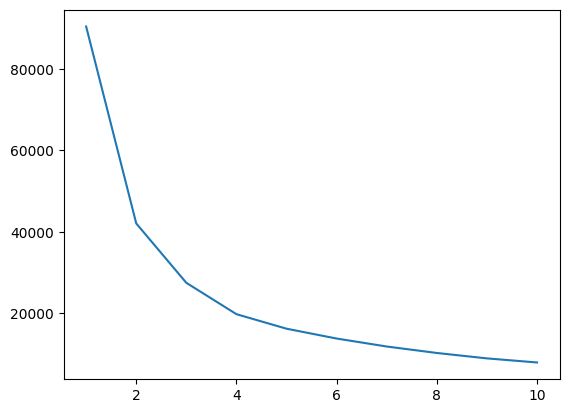

In [28]:
plt.plot(range(1,11),wcss)

In [29]:
kmeans = KMeans(n_init = 20, n_clusters = 4)

In [30]:
y_kmeans = kmeans.fit_predict(X)

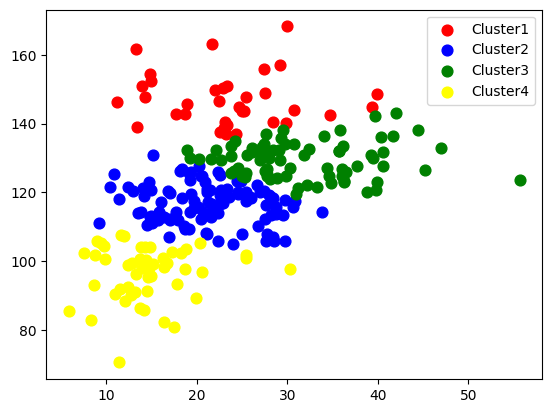

In [31]:
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s = 60, c = 'red', label = 'Cluster1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s = 60, c = 'blue', label = 'Cluster2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s = 60, c = 'green', label = 'Cluster3')
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s = 60, c = 'yellow', label = 'Cluster4')

plt.legend()

plt.show()